## Sorry AI — You Still Can’t take these”

A peek into the change of skills in demand in the recent years and how you can prepare yourself for it!

In [76]:
## first, importing the basic libraries!
from pytrends.request import TrendReq
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from glob import glob
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose
import scipy.stats as stats



In [44]:
## combining the postings individual linkedin datasets into one
folder_path_s = "H1B_Newsletter/individual_user_skill" 


# Find all CSV files (including subfolders if any)
csv_files_skill = glob(f"{folder_path_s}/**/*.csv", recursive=True)

print(f"Found {len(csv_files_skill)} CSV files")

# Load and combine them all
skills_df = pd.concat(
    (pd.read_csv(f) for f in csv_files_skill),
    ignore_index=True
)

print("Combined shape:", skills_df.shape)
print("Columns:", skills_df.columns.tolist())

Found 48 CSV files


KeyboardInterrupt: 

In [ ]:
# ================== Save as one CSV ==================
output_filename = "all_skills_combined.csv"

skills_df.to_csv(output_filename, index=False)

print(f" Successfully saved as '{output_filename}'")
print(f"File size: {skills_df.shape[0]:,} rows × {skills_df.shape[1]} columns")

 Successfully saved as 'all_skills_combined.csv'
File size: 91,972,181 rows × 4 columns


In [80]:
monthly_postings = pd.read_csv("CSV_files/postings_combined.csv")

In [ ]:
## combining the postings individual linkedin datasets into one
folder_path_ct = "H1B_Newsletter/wf_dynam_role_breakdown" 


# Find all CSV files (including subfolders if any)
csv_files_count = glob(f"{folder_path_ct}/**/*.csv", recursive=True)

print(f"Found {len(csv_files_count)} CSV files")

# Load and combine them all
count_df = pd.concat(
    (pd.read_csv(f) for f in csv_files_count),
    ignore_index=True
)

print("Combined shape:", count_df.shape)
print("Columns:", count_df.columns.tolist())

Found 32 CSV files
Combined shape: (10239812, 17)
Columns: ['rcid', 'company', 'region', 'seniority', 'role_k10', 'role_k50', 'role_k150', 'month', 'count', 'inflow', 'outflow', 'external_inflow', 'external_outflow', 'salary', 'duration', 'total_prestige', 'prestige_weight']


In [ ]:
count_df= pd.read_csv("CSV_files/wf_count.csv")

In [ ]:
print(count_df.head())
print(monthly_postings.head())

      rcid       company          region  seniority role_k10  \
0  1223555  NVIDIA Corp.  Western Europe          2  Finance   
1  1223555  NVIDIA Corp.  Western Europe          2  Finance   
2  1223555  NVIDIA Corp.  Western Europe          2  Finance   
3  1223555  NVIDIA Corp.  Western Europe          2  Finance   
4  1223555  NVIDIA Corp.  Western Europe          2  Finance   

            role_k50          role_k150    month     count  inflow  outflow  \
0  Financial Analyst  Financial Analyst  2014-09  1.364782     0.0      0.0   
1  Financial Analyst  Financial Analyst  2014-10  1.364782     0.0      0.0   
2  Financial Analyst  Financial Analyst  2014-11  1.364782     0.0      0.0   
3  Financial Analyst  Financial Analyst  2014-12  1.364782     0.0      0.0   
4  Financial Analyst  Financial Analyst  2015-01  1.364782     0.0      0.0   

   external_inflow  external_outflow         salary  duration  total_prestige  \
0              0.0               0.0  106419.812500       0

In [ ]:
company_mapping= pd.read_csv("CSV_files/company_mapping.csv")

In [ ]:
print(monthly_postings['company'].unique())

<StringArray>
[             'Microsoft Corp.',             'Activision, Inc.',
 'Advanced Micro Devices, Inc.',                 'NVIDIA Corp.',
                   'Google LLC',         'Meta Platforms, Inc.',
                    'Waymo LLC',                  'Intel Corp.',
                 'Google Cloud',        'Playground Games Ltd.',
 ...
       'JML International Ltd.', 'Plexo Capital Management LLC',
                'Airsoft, Inc.',    'Ready at Dawn Studios LLC',
   'Intel Technology Sdn. Bhd.',        'Neverware Europe Ltd.',
                 'Fitbit, Inc.',                   'BOPS, Inc.',
             'Softricity, Inc.',        'GV Management Co. LLC']
Length: 158, dtype: str


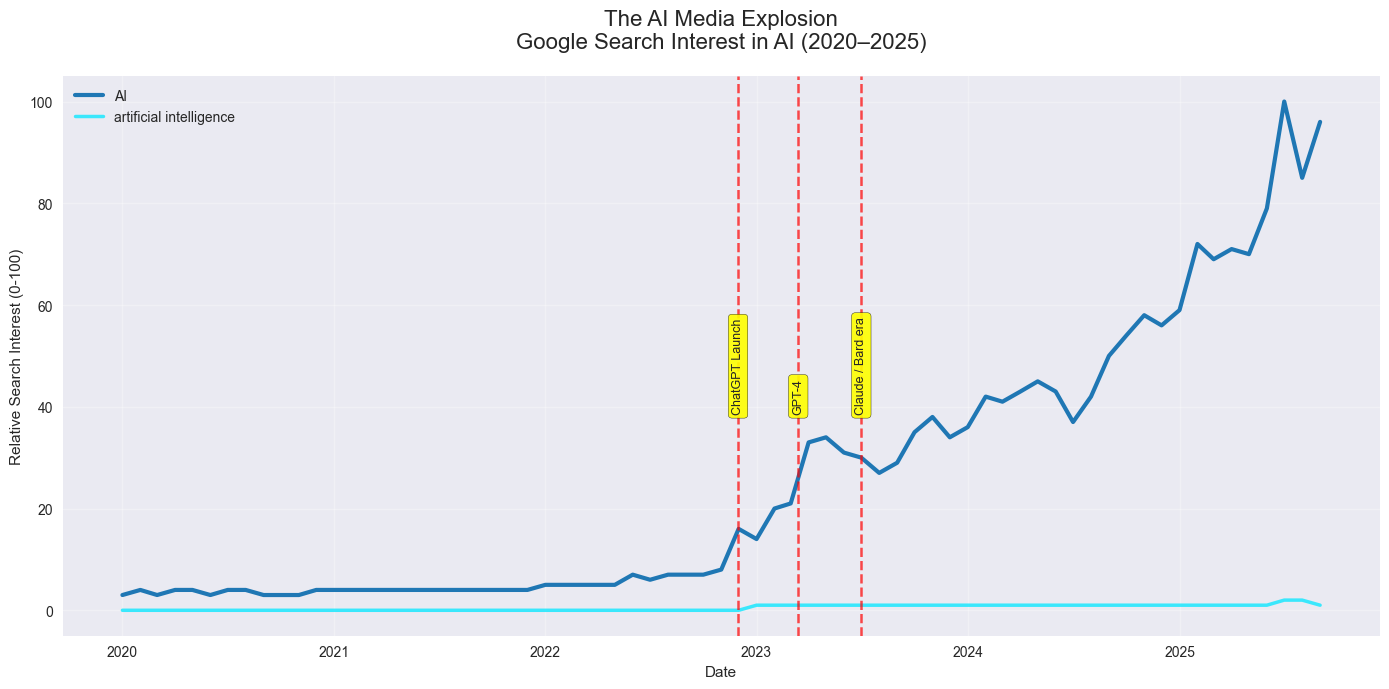

In [ ]:
## we will be looking at "AI/artificail intelligence" trends in news headlines
plt.style.use('seaborn-v0_8')

# Fetch Google Trends data
pytrends = TrendReq(hl='en-US', tz=360)
pytrends.build_payload(["AI", "artificial intelligence"], 
                       timeframe='2020-01-01 2025-09-07', 
                       geo='US')

df_ai = pytrends.interest_over_time()

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_ai.index, df_ai['AI'], label='AI', linewidth=3, color='#1f77b4')
ax.plot(df_ai.index, df_ai['artificial intelligence'], label='artificial intelligence', 
        linewidth=2.5, color="#0ee7ff", alpha=0.8)
# Key AI milestones
events = {
    'ChatGPT Launch': '2022-11-30',
    'GPT-4': '2023-03-14',
    'Claude / Bard era': '2023-07-01'
}

for label, date_str in events.items():
    date = datetime.datetime.strptime(date_str, '%Y-%m-%d')
    ax.axvline(x=date, color='red', linestyle='--', linewidth=1.8, alpha=0.7)
    ax.annotate(label, xy=(date, 35), xytext=(0, 15), textcoords='offset points',
                ha='center', fontsize=9, rotation=90,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.9))

ax.set_title("The AI Media Explosion\nGoogle Search Interest in AI (2020–2025)", fontsize=16, pad=20)
ax.set_xlabel("Date")
ax.set_ylabel("Relative Search Interest (0-100)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
plt.style.use('seaborn-v0_8')

postings_monthly = pd.read_csv('CSV_files/postings_combined.csv')
# Use the postings dataframe you already have open
df = postings_monthly.copy()
df_clean = df[df['role_k10'] != 'unknown'].copy() ## I will be removing any role that doesn't have a knwon role


In [82]:
# Calculate filling time
df_clean['post_date'] = pd.to_datetime(df_clean['post_date'], errors='coerce')
df_clean['remove_date'] = pd.to_datetime(df_clean['remove_date'], errors='coerce')
df_clean['filling_time_days'] = (df_clean['remove_date'] - df_clean['post_date']).dt.days
df_clean['filling_time_months'] = df_clean['filling_time_days'] / 30.44
df_clean['Month'] = df_clean['post_date'].dt.to_period('M').dt.to_timestamp()

In [83]:

monthly = df_clean.groupby('Month').agg(
    Filling_time_avg=('filling_time_months', 'mean')
).reset_index()

monthly = monthly.set_index('Month')

# Seasonal adjustment
decomp = seasonal_decompose(monthly['Filling_time_avg'], model='additive', period=12)
monthly['Filling_time_seasonally_adjusted'] = monthly['Filling_time_avg'] - decomp.seasonal

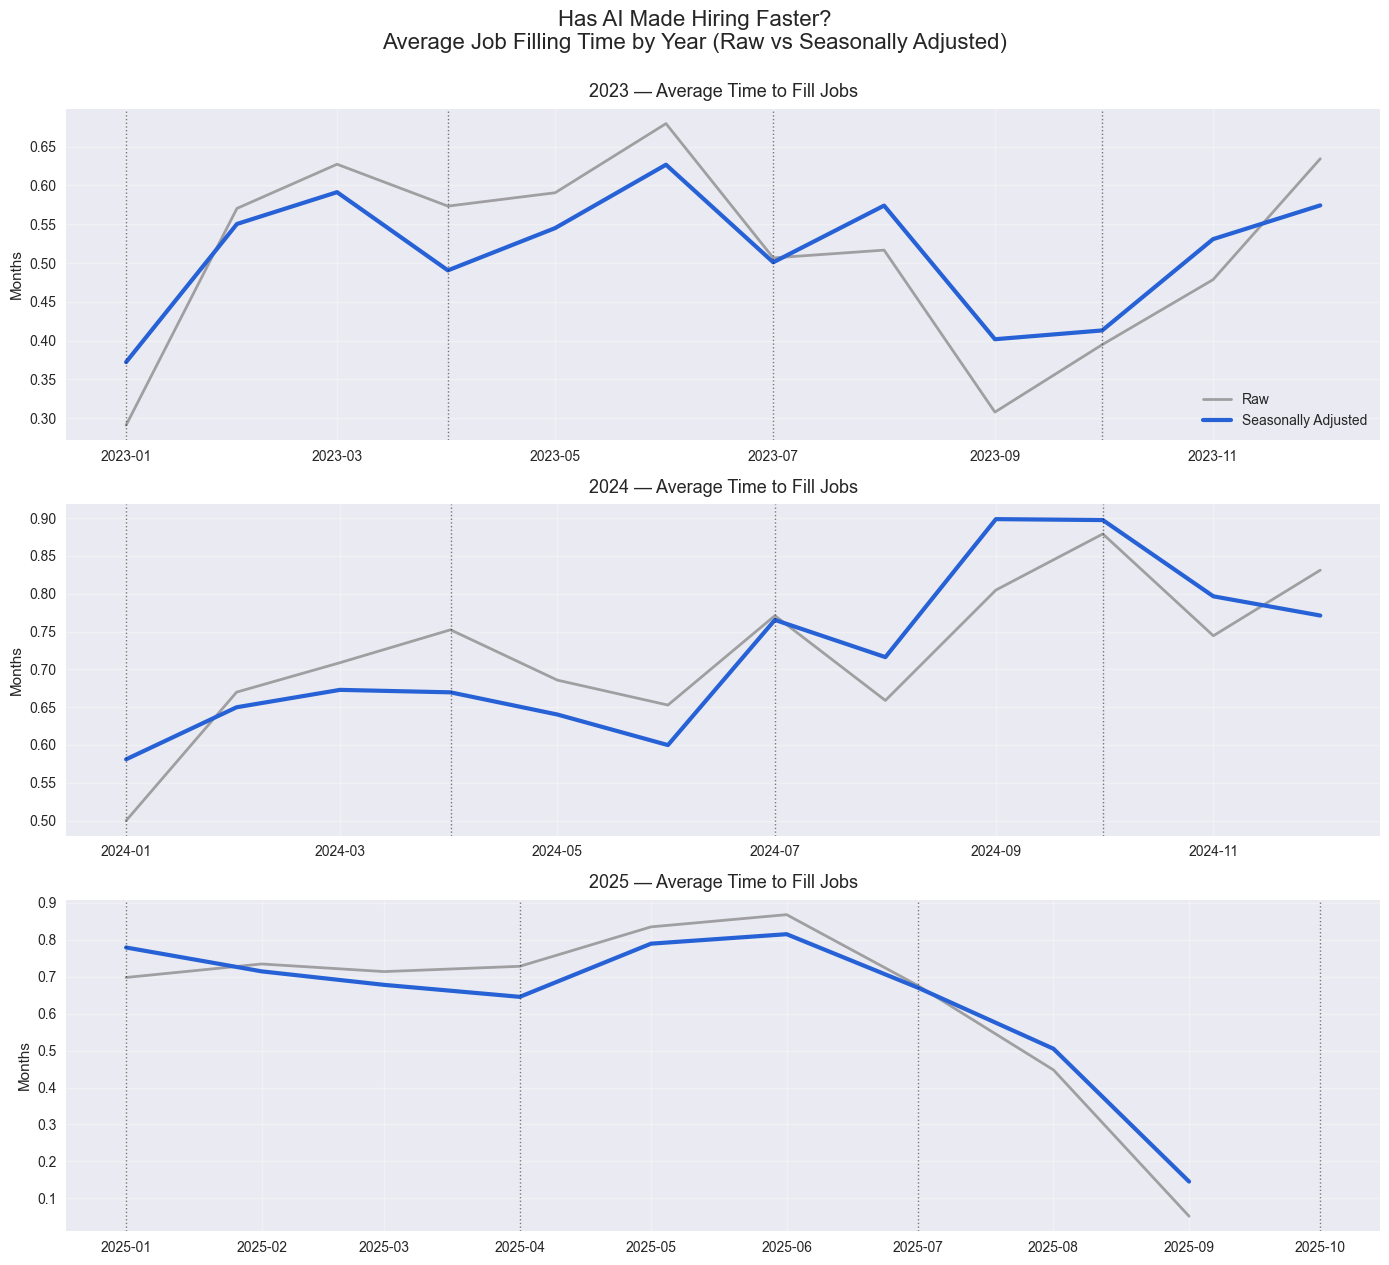

In [49]:
# ================== Plot with Unified Quarters ==================
years = [2023, 2024, 2025]
fig, axes = plt.subplots(len(years), 1, figsize=(14, 4.2 * len(years)), sharey=False)

for i, year in enumerate(years):
    ax = axes[i]
    
    # Filter data for this year
    year_data = monthly[monthly.index.year == year].copy()
    
    # Plot both series
    ax.plot(year_data.index, year_data['Filling_time_avg'], 
            label='Raw', linewidth=2, color='gray', alpha=0.7)
    ax.plot(year_data.index, year_data['Filling_time_seasonally_adjusted'], 
            label='Seasonally Adjusted', linewidth=3, color="#2761d6")
    
    # === Unified Quarter Lines (always Jan, Apr, Jul, Oct) ===
    for q in [1, 4, 7, 10]:   # start of each quarter
        q_date = pd.Timestamp(f"{year}-{q:02d}-01")
        ax.axvline(x=q_date, color='black', linestyle=':', alpha=0.5, linewidth=1)
    
    # Title and labels
    ax.set_title(f"{year} — Average Time to Fill Jobs", fontsize=13, pad=8)
    ax.set_ylabel("Months")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend()

    # Highlight AI Boom in 2022
    if year == 2022:
        ai_date = datetime.datetime(2022, 11, 30)
        ax.axvline(x=ai_date, color='red', linestyle='--', linewidth=2.5, alpha=0.85)
        ax.annotate('AI Boom\n(ChatGPT)', xy=(ai_date, 0.35), 
                    xytext=(10, 10), textcoords='offset points', 
                    fontsize=9, color='red')

# Overall title
fig.suptitle("Has AI Made Hiring Faster?\nAverage Job Filling Time by Year (Raw vs Seasonally Adjusted)", 
             fontsize=16, y=1)

plt.tight_layout()
plt.show()

In [50]:
# Monthly per-role data
monthly_role = df_clean.groupby(['Month', 'role_k10']).agg(
    Filling_time_avg=('filling_time_months', 'mean')
).reset_index()

# Overall seasonally adjusted average (market-wide)
monthly_overall = df_clean.groupby('Month').agg(
    Filling_time_avg=('filling_time_months', 'mean')
).reset_index().set_index('Month')

decomp = seasonal_decompose(monthly_overall['Filling_time_avg'], model='additive', period=12)
monthly_overall['Filling_time_seasonally_adjusted'] = monthly_overall['Filling_time_avg'] - decomp.seasonal

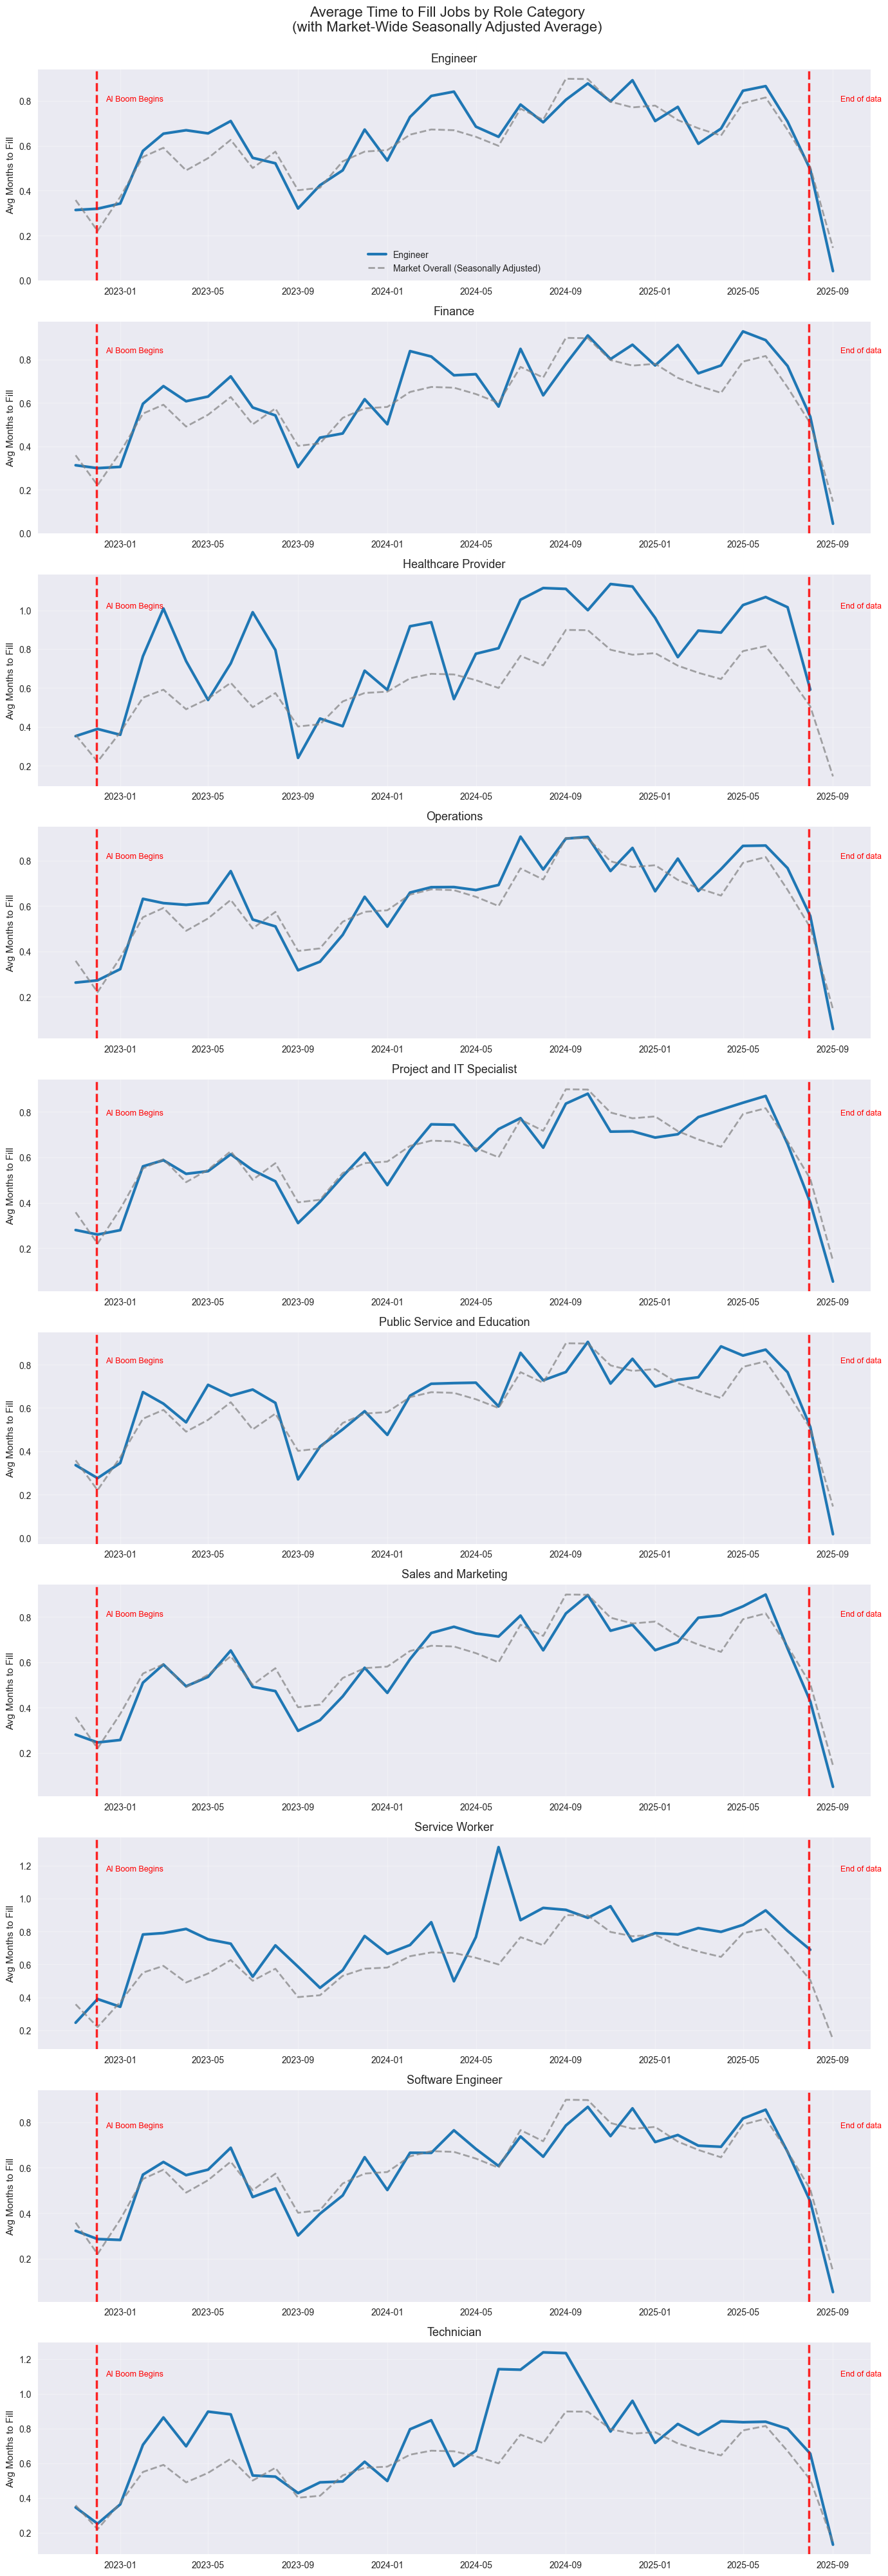

In [51]:
# ================== Subplots with grey overall line ==================
roles = sorted(monthly_role['role_k10'].unique())
fig, axes = plt.subplots(len(roles), 1, figsize=(14, 4 * len(roles)), sharex=False)

for i, role in enumerate(roles):
    ax = axes[i]
    data = monthly_role[monthly_role['role_k10'] == role]
    
    # Role-specific line
    ax.plot(data['Month'], data['Filling_time_avg'], 
            label=role, linewidth=3, color='#1f77b4')
    
    # Grey overall seasonally adjusted line
    ax.plot(monthly_overall.index, monthly_overall['Filling_time_seasonally_adjusted'], 
            label='Market Overall (Seasonally Adjusted)', 
            linewidth=2, color='gray', alpha=0.7, linestyle='--')
    
    ax.set_title(f"{role}", fontsize=13, pad=8)
    ax.set_ylabel("Avg Months to Fill")
    ax.grid(True, alpha=0.3)
    
    if i == 0:  # legend only on first subplot
        ax.legend()

    # AI Boom marker
    if 2022 in data['Month'].dt.year.values:
        ax.axvline(x=datetime.datetime(2022, 11, 30), color='red', linestyle='--', linewidth=2.5, alpha=0.85)
        ax.annotate('AI Boom Begins', xy=(datetime.datetime(2022, 11, 30), data['Filling_time_avg'].max()*0.85),
                    xytext=(10, 10), textcoords='offset points', fontsize=9, color='red')
    ## end marker
    if 2025 in data['Month'].dt.year.values:
        ax.axvline(x=datetime.datetime(2025, 7, 30), color='red', linestyle='--', linewidth=2.5, alpha=0.85)
        ax.annotate('End of data', 
                    xy=(datetime.datetime(2025, 8, 30), data['Filling_time_avg'].max()*0.85),
                    xytext=(10, 10), textcoords='offset points', fontsize=9, color='red')

fig.suptitle("Average Time to Fill Jobs by Role Category\n(with Market-Wide Seasonally Adjusted Average)", 
             fontsize=16, y=1)
plt.tight_layout()
plt.show()

In [52]:
# ================== Variance / Standard Deviation of Time to Fill by Role ==================
# Calculate mean and standard deviation per role
role_stats = df_clean.groupby('role_k10').agg(
    mean_filling_time=('filling_time_months', 'mean'),
    std_filling_time=('filling_time_months', 'std'),
    variance_filling_time=('filling_time_months', 'var'),
    num_jobs=('filling_time_months', 'count')
).round(3)

# Sort by highest variability (standard deviation)
role_stats = role_stats.sort_values('std_filling_time', ascending=False)

print("Top 10 roles by variability (std dev) of filling time:")
print(role_stats.head(10)[['mean_filling_time', 'std_filling_time', 'variance_filling_time', 'num_jobs']])


Top 10 roles by variability (std dev) of filling time:
                              mean_filling_time  std_filling_time  \
role_k10                                                            
Technician                                0.667             0.636   
Healthcare Provider                       0.722             0.558   
Finance                                   0.632             0.551   
Service Worker                            0.735             0.545   
Operations                                0.614             0.526   
Engineer                                  0.623             0.516   
Public Service and Education              0.608             0.504   
Project and IT Specialist                 0.610             0.439   
Software Engineer                         0.601             0.438   
Sales and Marketing                       0.620             0.434   

                              variance_filling_time  num_jobs  
role_k10                                            

/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_53455/3574173706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


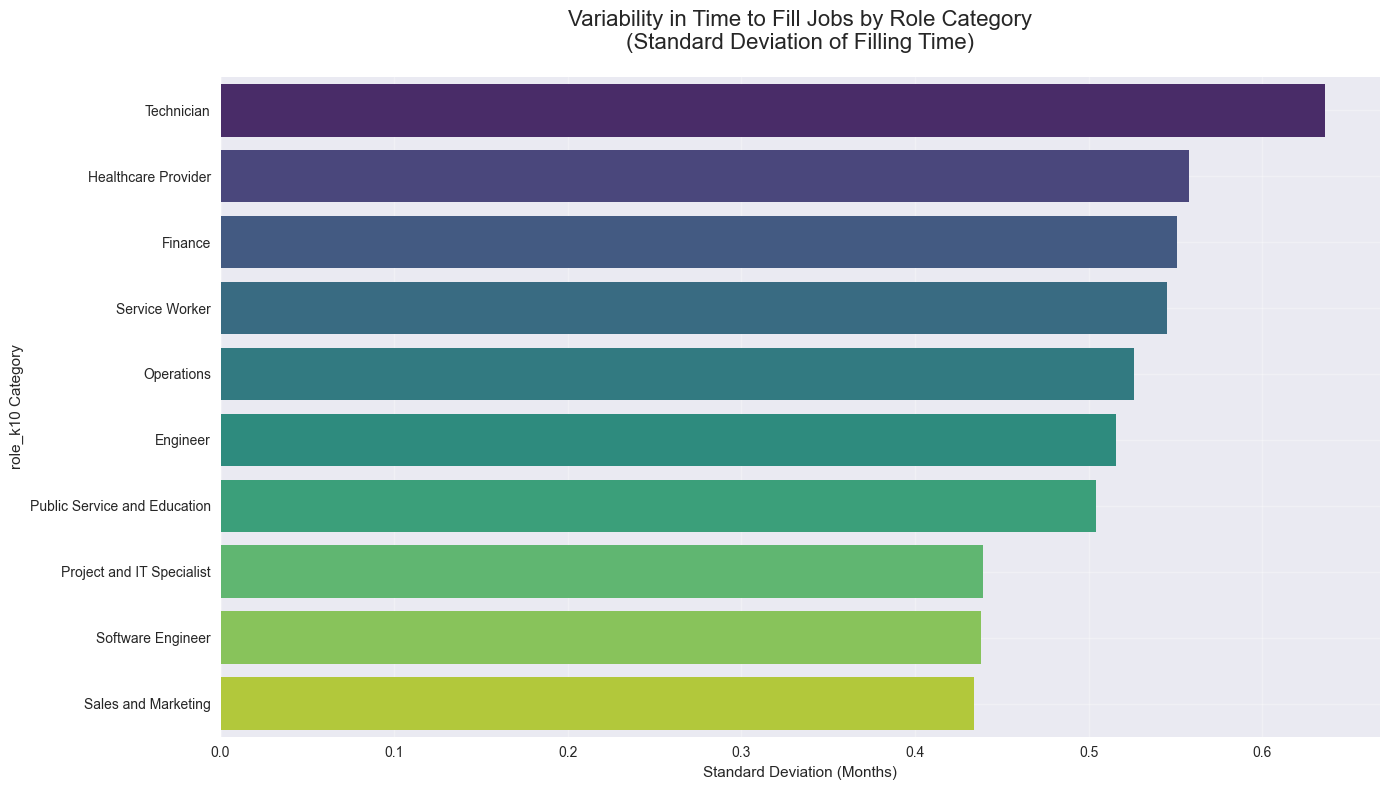

In [53]:
# ================== Bar Plot ==================
fig, ax = plt.subplots(figsize=(14, 8))

sns.barplot(
    data=role_stats.reset_index().head(12), 
    x='std_filling_time', 
    y='role_k10',
    palette="viridis"
)

ax.set_title("Variability in Time to Fill Jobs by Role Category\n(Standard Deviation of Filling Time)", 
             fontsize=16, pad=20)
ax.set_xlabel("Standard Deviation (Months)")
ax.set_ylabel("role_k10 Category")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_53455/757958061.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


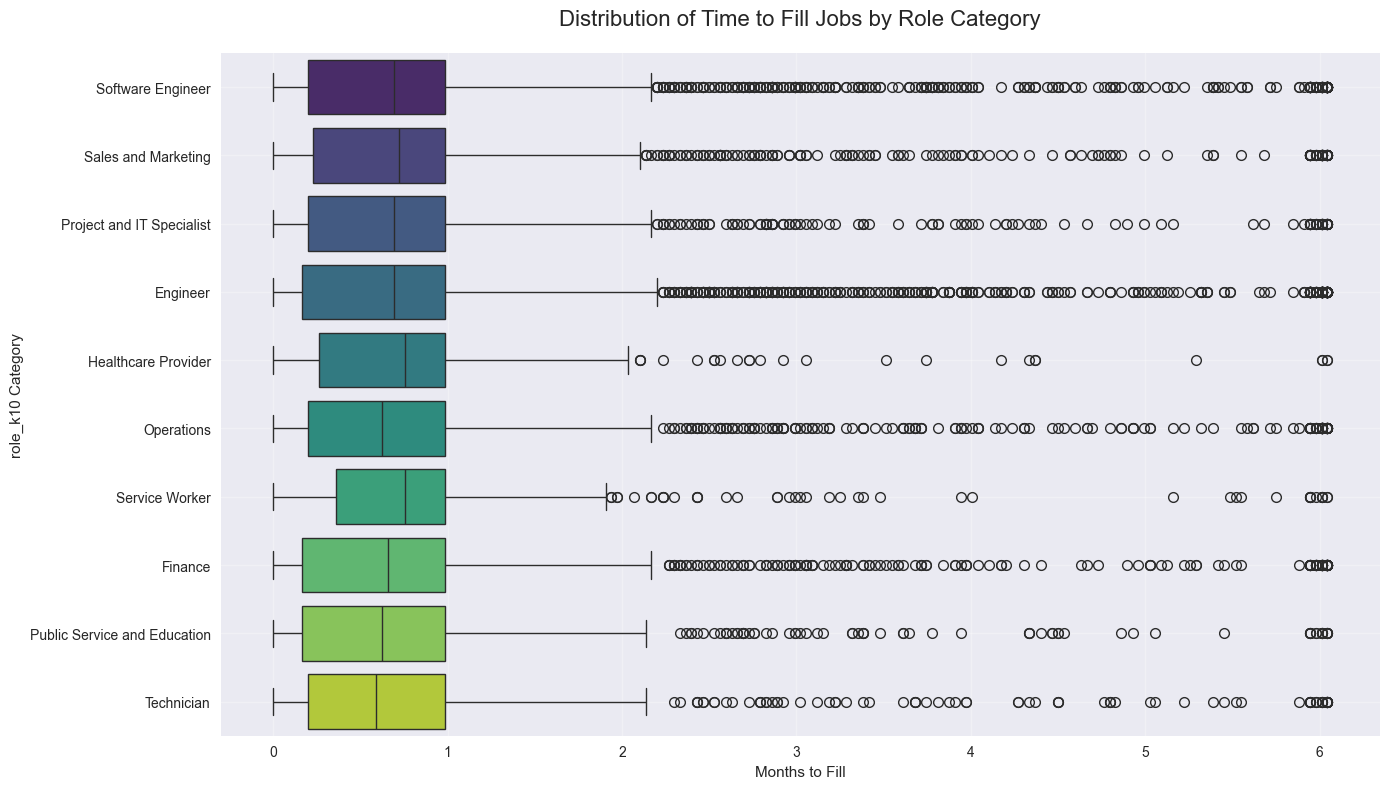

In [54]:


# ================== Box Plot ==================
fig, ax = plt.subplots(figsize=(14, 8))

sns.boxplot(
    data=df_clean,
    x='filling_time_months',
    y='role_k10',          
    palette="viridis",
    showfliers=True
)

ax.set_title("Distribution of Time to Fill Jobs by Role Category", 
             fontsize=16, pad=20)
ax.set_xlabel("Months to Fill")
ax.set_ylabel("role_k10 Category")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
# ================== Percentage of Outliers by role_k10 ==================
# Function to count upper outliers
def count_upper_outliers(group):
    if len(group) < 4:
        return 0
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    return (group > upper_bound).sum()

# Calculate outliers per role
outlier_counts = df_clean.groupby('role_k10')['filling_time_months'] \
    .apply(count_upper_outliers) \
    .reset_index(name='num_outliers')

# Total postings per role
total_per_role = df_clean.groupby('role_k10').size().reset_index(name='total_postings')

# Merge and calculate percentage
result = outlier_counts.merge(total_per_role, on='role_k10')
result['percentage'] = (result['num_outliers'] / result['total_postings'] * 100).round(2)

# Sort by highest percentage
result = result.sort_values('percentage', ascending=False)

print("Percentage of Outliers by role_k10 (sorted by highest %):\n")
print(result[['role_k10', 'num_outliers', 'total_postings', 'percentage']].to_string(index=False))

Percentage of Outliers by role_k10 (sorted by highest %):

                    role_k10  num_outliers  total_postings  percentage
                  Technician            85            7184        1.18
              Service Worker            46            5213        0.88
         Healthcare Provider            25            2882        0.87
                     Finance           188           33840        0.56
                  Operations           208           36963        0.56
                    Engineer           563          128888        0.44
Public Service and Education            75           20113        0.37
   Project and IT Specialist           142          126570        0.11
         Sales and Marketing           195          192376        0.10
           Software Engineer           392          549464        0.07


In [ ]:
print(df_clean.columns)

Index(['job_id', 'rcid', 'company', 'rics_k50', 'rics_k200', 'rics_k400',
       'title_raw', 'title_translated', 'role_k10', 'role_k50', 'role_k150',
       'role_k1500', 'mapped_role', 'country', 'state', 'salary', 'post_date',
       'remove_date', 'ultimate_parent_rcid', 'ultimate_parent_company_name',
       'remote_type', 'filling_time_days', 'filling_time_months', 'Month'],
      dtype='str')


In [57]:
# === ONE-TIME: Add upper_bound and is_outlier to df_clean (preserves all columns) ===

# 1. Calculate upper_bound per role_k10
def get_upper_bound(g):
    if len(g) < 4:
        return np.nan
    Q1 = g.quantile(0.25)
    Q3 = g.quantile(0.75)
    IQR = Q3 - Q1
    return round(Q3 + 1.5 * IQR, 3)

upper_bounds = df_clean.groupby('role_k10')['filling_time_months'].apply(get_upper_bound)
upper_bounds.name = 'upper_bound'

# 2. Merge upper_bound back to df_clean
df_clean = df_clean.merge(upper_bounds, on='role_k10', how='left')

# 3. Add is_outlier flag
df_clean['is_outlier'] = df_clean['filling_time_months'] > df_clean['upper_bound']

print("✅ Successfully added 'upper_bound' and 'is_outlier' to df_clean")
print("Columns now include:", list(df_clean.columns))
print(df_clean[['role_k10', 'filling_time_months', 'upper_bound', 'is_outlier']].head())

✅ Successfully added 'upper_bound' and 'is_outlier' to df_clean
Columns now include: ['job_id', 'rcid', 'company', 'rics_k50', 'rics_k200', 'rics_k400', 'title_raw', 'title_translated', 'role_k10', 'role_k50', 'role_k150', 'role_k1500', 'mapped_role', 'country', 'state', 'salary', 'post_date', 'remove_date', 'ultimate_parent_rcid', 'ultimate_parent_company_name', 'remote_type', 'filling_time_days', 'filling_time_months', 'Month', 'upper_bound', 'is_outlier']
                    role_k10  filling_time_months  upper_bound  is_outlier
0          Software Engineer             0.689882        2.168       False
1        Sales and Marketing             0.098555        2.119       False
2          Software Engineer             0.985545        2.168       False
3  Project and IT Specialist             0.985545        2.168       False
4          Software Engineer             0.492773        2.168       False


In [58]:
summary = (
    df_clean
    .groupby('role_k10')
    .agg(
        upper_bound=('upper_bound', 'first'),
        num_outliers=('is_outlier', 'sum'),
        total_postings=('role_k10', 'size')
    )
    .reset_index()
)

summary['percentage'] = (summary['num_outliers'] / summary['total_postings'] * 100).round(2)
summary = summary.sort_values('total_postings', ascending=False).reset_index(drop=True)

print(summary[['role_k10', 'upper_bound', 'num_outliers', 
               'total_postings', 'percentage']].to_string(index=False))

                    role_k10  upper_bound  num_outliers  total_postings  percentage
           Software Engineer        2.168           403          549464        0.07
         Sales and Marketing        2.119           195          192376        0.10
                    Engineer        2.217           563          128888        0.44
   Project and IT Specialist        2.168           146          126570        0.12
                  Operations        2.168           212           36963        0.57
                     Finance        2.217           188           33840        0.56
Public Service and Education        2.217            75           20113        0.37
                  Technician        2.168            85            7184        1.18
              Service Worker        1.922            46            5213        0.88
         Healthcare Provider        2.070            25            2882        0.87


In [59]:
# === Outlier Probability per role_k10 (using existing columns only) ===

(
    df_clean
    .groupby('role_k10')
    .agg(
        upper_bound=('upper_bound', 'first'),
        num_outliers=('is_outlier', 'sum'),
        total_postings=('role_k10', 'size')
    )
    .reset_index()
    .assign(percentage=lambda x: (x['num_outliers'] / x['total_postings'] * 100).round(2))
    .sort_values('total_postings', ascending=False)
    [['role_k10', 'upper_bound', 'num_outliers', 'total_postings', 'percentage']]
    .pipe(print)
)


                       role_k10  upper_bound  num_outliers  total_postings  \
8             Software Engineer        2.168           403          549464   
6           Sales and Marketing        2.119           195          192376   
0                      Engineer        2.217           563          128888   
4     Project and IT Specialist        2.168           146          126570   
3                    Operations        2.168           212           36963   
1                       Finance        2.217           188           33840   
5  Public Service and Education        2.217            75           20113   
9                    Technician        2.168            85            7184   
7                Service Worker        1.922            46            5213   
2           Healthcare Provider        2.070            25            2882   

   percentage  
8        0.07  
6        0.10  
0        0.44  
4        0.12  
3        0.57  
1        0.56  
5        0.37  
9        1.18

/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_53455/2640017106.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_53455/2640017106.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal', 'Unusual'])
/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_53455/2640017106.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_53455/2640017106.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks

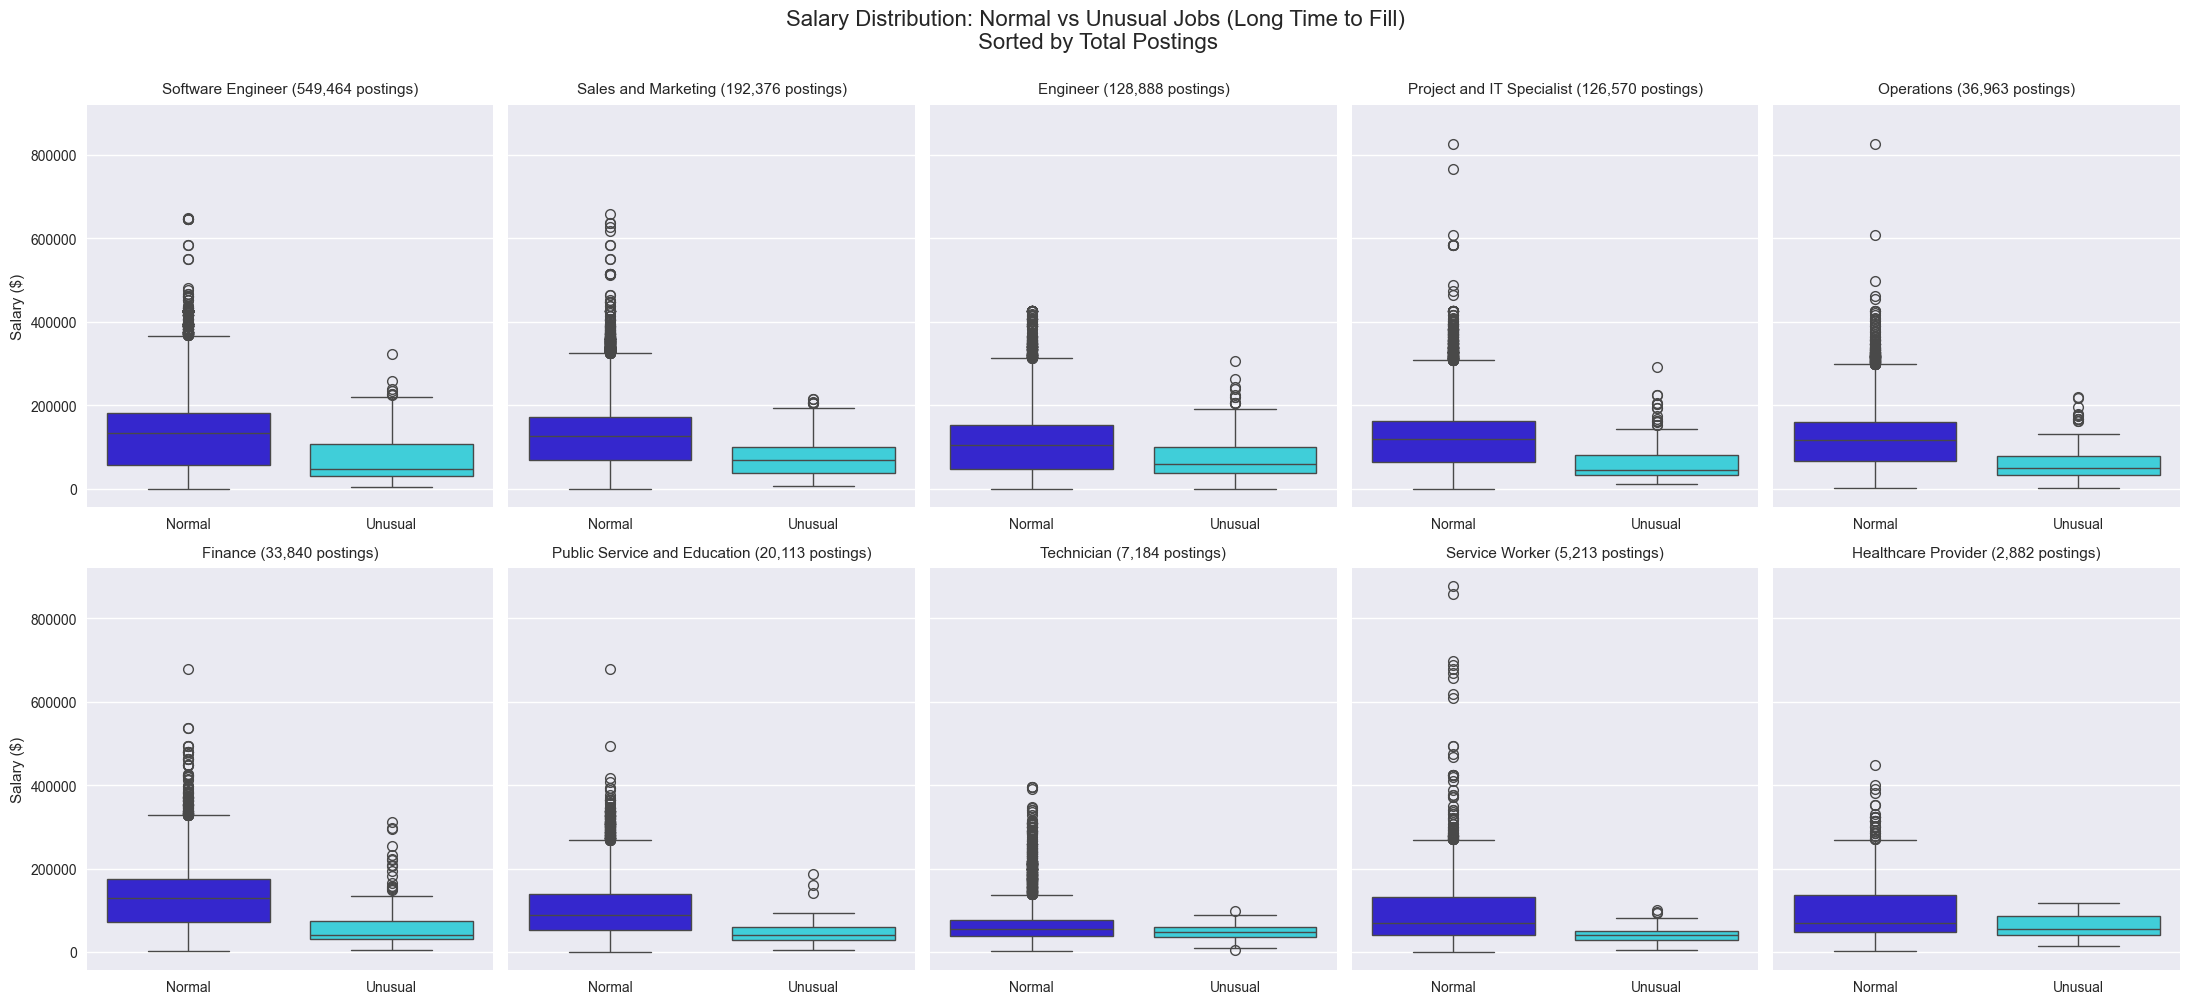

In [56]:
# ================== Salary Distribution: Normal vs Outliers — Sorted by Total Postings ==================

# Get all 10 roles sorted by total number of postings (highest first)
role_order = df_clean['role_k10'].value_counts().index.tolist()

# ================== Subplots with shared Y-axis ==================
fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharey=True)
axes = axes.flatten()

for i, role in enumerate(role_order):
    ax = axes[i]
    data = df_clean[df_clean['role_k10'] == role].copy()
    
    # Mark outliers
    Q1 = data['filling_time_months'].quantile(0.25)
    Q3 = data['filling_time_months'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    data['is_outlier'] = data['filling_time_months'] > upper_bound
    
    sns.boxplot(
        data=data,
        x='is_outlier',
        y='salary',
        ax=ax,
        palette=["#1e0be9", "#27e4f2"]
    )
    
    ax.set_title(f"{role} ({data.shape[0]:,} postings)", fontsize=11, pad=8)
    ax.set_xlabel('')
    ax.set_xticklabels(['Normal', 'Unusual'])
    
    if i % 5 == 0:
        ax.set_ylabel("Salary ($)")
    else:
        ax.set_ylabel("")

# Hide any unused subplot (safety)
for j in range(len(role_order), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Salary Distribution: Normal vs Unusual Jobs (Long Time to Fill)\n Sorted by Total Postings", 
             fontsize=16, y=1)
plt.tight_layout()
plt.show()

For Healthcare, Service Worker, Technician, and Public Service & Education roles, there are almost no high-salary outliers among jobs that take unusually long to fill.
This suggests these positions face a structural talent shortage: companies are not able (or willing) to use significantly higher pay to close the gap quickly. As a result, these roles tend to remain open longer.
The “HOWEVER” part is a great place to contrast with technical roles:
However, for Software Engineer and other technical roles, we see the opposite pattern: many long-to-fill positions come with very high salary outliers. This implies companies are aggressively using compensation to compete for scarce technical talent.

In [ ]:
# === CREATE monthly_country (run this first) ===
import pandas as pd

# Aggregate average filling time by month + country
monthly_country = (
    df_clean.groupby(['Month', 'country'])['filling_time_months']   # or whatever your time column is called
    .mean()
    .reset_index()
)

# Convert Period to datetime so matplotlib can plot it nicely
monthly_country['Month'] = monthly_country['Month'].dt.to_timestamp()

AttributeError: 'DatetimeProperties' object has no attribute 'to_timestamp'

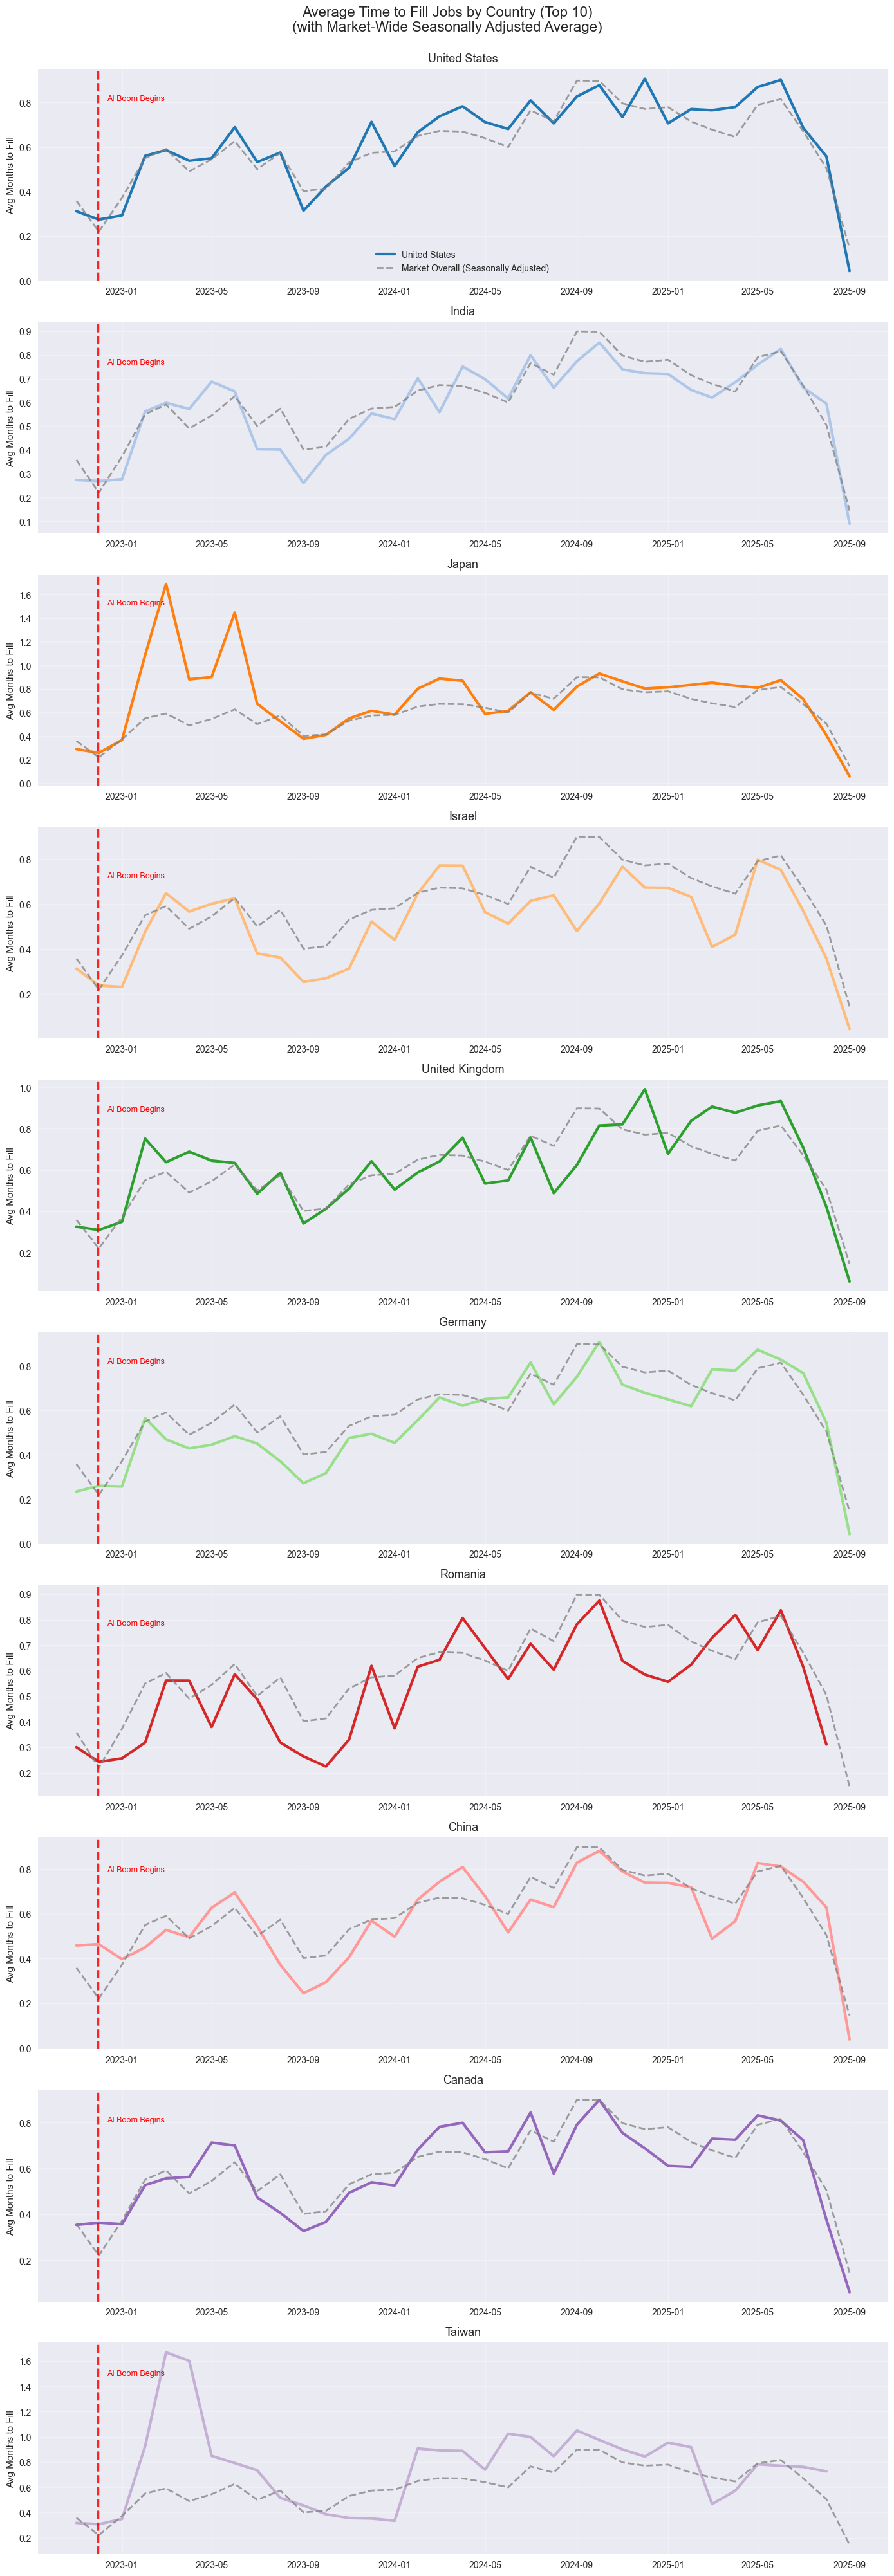

In [ ]:
# ================== Subplots by Country (Top 10) with same colors as big plot ==================

# Top 10 countries (same as big plot)
top_countries = df_clean['country'].value_counts().head(10).index.tolist()

# Use the same distinct color palette as the big plot
country_color_map = dict(zip(top_countries, colors))

# ================== Plot one subplot per country ==================
fig, axes = plt.subplots(len(top_countries), 1, figsize=(14, 4 * len(top_countries)), sharex=False)

for i, country in enumerate(top_countries):
    ax = axes[i]
    data = monthly_country[monthly_country['country'] == country]
    
    # Country-specific line (same color as in big plot)
    ax.plot(data['Month'], data['Filling_time_avg'], 
            label=country, linewidth=3, color=country_color_map[country])
    
    # Grey overall seasonally adjusted market line
    ax.plot(monthly_overall.index, monthly_overall['Filling_time_seasonally_adjusted'], 
            label='Market Overall (Seasonally Adjusted)', 
            linewidth=2, color='gray', alpha=0.75, linestyle='--')
    
    ax.set_title(f"{country}", fontsize=13, pad=8)
    ax.set_ylabel("Avg Months to Fill")
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend()

    # AI Boom marker
    if 2022 in data['Month'].dt.year.values:
        ax.axvline(x=datetime.datetime(2022, 11, 30), color='red', linestyle='--', linewidth=2.5, alpha=0.85)
        ax.annotate('AI Boom Begins', xy=(datetime.datetime(2022, 11, 30), data['Filling_time_avg'].max()*0.85),
                    xytext=(10, 10), textcoords='offset points', fontsize=9, color='red')

fig.suptitle("Average Time to Fill Jobs by Country (Top 10)\n(with Market-Wide Seasonally Adjusted Average)", 
             fontsize=16, y=1)
plt.tight_layout()
plt.show()

/var/folders/fc/1ht7kmfs0_56nvwc76srygf80000gn/T/ipykernel_21624/2521202646.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


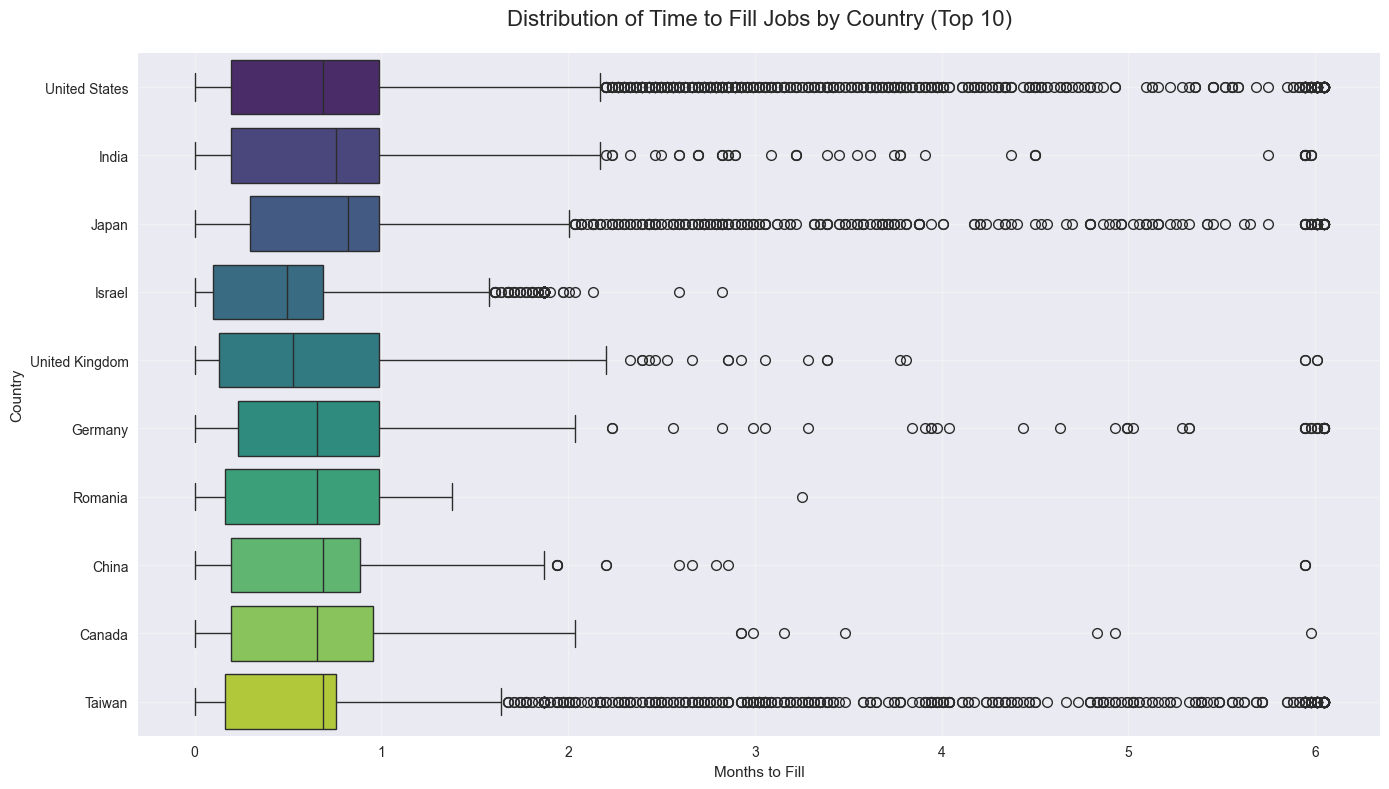

In [ ]:
# ================== Box Plot: Distribution of Filling Time by Country ==================

# Top 10 countries by number of postings
top_countries = df_clean['country'].value_counts().head(10).index.tolist()

# Filter data
plot_data = df_clean[df_clean['country'].isin(top_countries)].copy()

# ================== Box Plot ==================
fig, ax = plt.subplots(figsize=(14, 8))

sns.boxplot(
    data=plot_data,
    x='filling_time_months',
    y='country',
    order=top_countries,
    palette="viridis",
    showfliers=True
)

ax.set_title("Distribution of Time to Fill Jobs by Country (Top 10)", 
             fontsize=16, pad=20)
ax.set_xlabel("Months to Fill")
ax.set_ylabel("Country")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [66]:
# === Outlier Percentage per role_k10 (All countries combined) ===

result = (
    df_clean
    .groupby('role_k10')
    .agg(
        num_outliers=('is_outlier', 'sum'),
        total_postings=('role_k10', 'size')
    )
    .reset_index()
)

result['percentage'] = (result['num_outliers'] / result['total_postings'] * 100).round(2)

# Sort exactly like your boxplot (highest total postings first)
result = result.sort_values('total_postings', ascending=False).reset_index(drop=True)

print("=== Outlier Percentage by Role (All Countries Combined) ===\n")
print(result[['role_k10', 'num_outliers', 'total_postings', 'percentage']].to_string(index=False))

print("\n(percentage = chance that a job in this role is an outlier / long time to fill)")

=== Outlier Percentage by Role (All Countries Combined) ===

                    role_k10  num_outliers  total_postings  percentage
           Software Engineer           403          549464        0.07
         Sales and Marketing           195          192376        0.10
                    Engineer           563          128888        0.44
   Project and IT Specialist           146          126570        0.12
                  Operations           212           36963        0.57
                     Finance           188           33840        0.56
Public Service and Education            75           20113        0.37
                  Technician            85            7184        1.18
              Service Worker            46            5213        0.88
         Healthcare Provider            25            2882        0.87

(percentage = chance that a job in this role is an outlier / long time to fill)


In [70]:
# === Probability that an outlier job has low salary (bottom 50%) ===

def low_salary_outlier_stats(group):
    if len(group) < 4:
        return pd.Series({'total_outliers': 0, 'low_salary_outliers': 0})
    
    # Median salary for this role
    median_salary = group['salary'].median()
    
    # Filter to only unusual jobs (outliers)
    outliers = group[group['is_outlier'] == True]
    
    total_outliers = len(outliers)
    low_salary_outliers = (outliers['salary'] <= median_salary).sum()
    
    return pd.Series({
        'total_outliers': total_outliers,
        'low_salary_outliers': low_salary_outliers,
        'percentage_low_salary': round((low_salary_outliers / total_outliers * 100), 2) if total_outliers > 0 else 0.0
    })

# Calculate for each role
result = (
    df_clean
    .groupby('role_k10')
    .apply(low_salary_outlier_stats)
    .reset_index()
)

# Sort exactly like your boxplot (highest total postings first)
result = result.sort_values(
    by='role_k10', 
    key=lambda x: x.map({role: i for i, role in enumerate(role_order)})
).reset_index(drop=True)

print("=== Chance that an Unusual (Long Time to Fill) Job is Low-Salary ===\n")
print(result[['role_k10', 'total_outliers', 'low_salary_outliers', 
              'percentage_low_salary']].to_string(index=False))

print("\n(percentage_low_salary = % of outlier jobs that are in the bottom 50% salary for that role)")

=== Chance that an Unusual (Long Time to Fill) Job is Low-Salary ===

                    role_k10  total_outliers  low_salary_outliers  percentage_low_salary
           Software Engineer           403.0                330.0                  81.89
         Sales and Marketing           195.0                157.0                  80.51
                    Engineer           563.0                434.0                  77.09
   Project and IT Specialist           146.0                123.0                  84.25
                  Operations           212.0                199.0                  93.87
                     Finance           188.0                167.0                  88.83
Public Service and Education            75.0                 71.0                  94.67
                  Technician            85.0                 57.0                  67.06
              Service Worker            46.0                 42.0                  91.30
         Healthcare Provider            

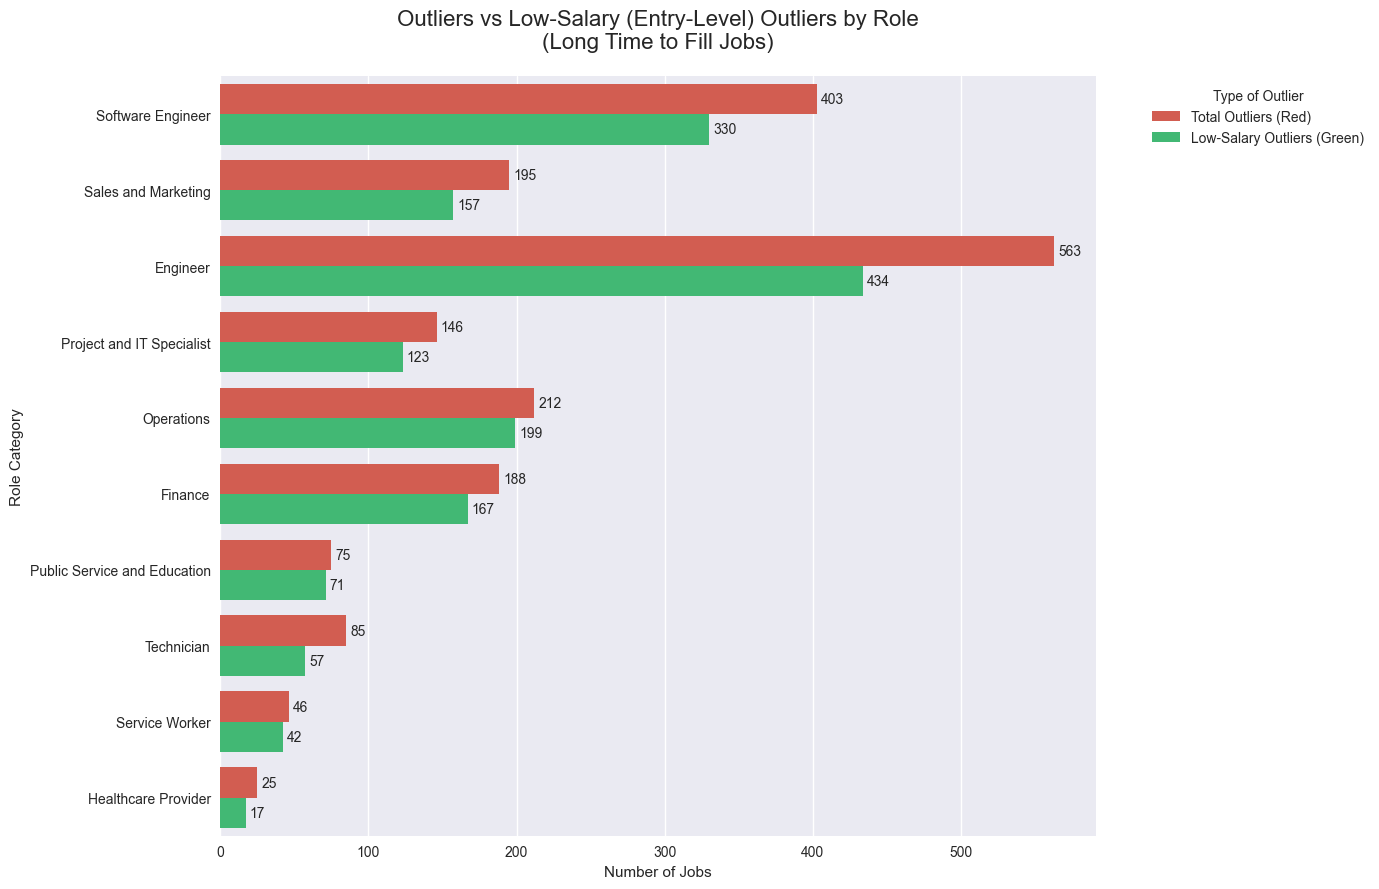

In [75]:
# === Horizontal Bar Chart (similar style to Revelio screenshot) ===

plt.figure(figsize=(14, 9))

# Melt for grouped bar chart
plot_data = result.melt(id_vars=['role_k10'], 
                        value_vars=['total_outliers', 'low_salary_outliers'],
                        var_name='type', 
                        value_name='count')

# Rename for nice legend
plot_data['type'] = plot_data['type'].map({
    'total_outliers': 'Total Outliers (Red)',
    'low_salary_outliers': 'Low-Salary Outliers (Green)'
})

sns.barplot(
    data=plot_data,
    y='role_k10',
    x='count',
    hue='type',
    palette=['#e74c3c', '#2ecc71'],   # red and green
    order=role_order
)

plt.title("Outliers vs Low-Salary (Entry-Level) Outliers by Role\n(Long Time to Fill Jobs)", 
          fontsize=16, pad=20)
plt.xlabel("Number of Jobs")
plt.ylabel("Role Category")

plt.legend(title="Type of Outlier", bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels
for container in plt.gca().containers:
    plt.bar_label(container, label_type='edge', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

In [73]:
# === Postings Share by role_k10 (as % of all postings) ===

postings_share = (
    df_clean
    .groupby('role_k10')
    .size()
    .reset_index(name='num_postings')
)

total_all_postings = postings_share['num_postings'].sum()

postings_share['percentage_of_total'] = (postings_share['num_postings'] / total_all_postings * 100).round(2)

# Sort exactly like your boxplot
postings_share = postings_share.set_index('role_k10').loc[role_order].reset_index()

print("=== Number of Postings per Role as % of All Postings ===\n")
print(postings_share[['role_k10', 'num_postings', 'percentage_of_total']].to_string(index=False))

=== Number of Postings per Role as % of All Postings ===

                    role_k10  num_postings  percentage_of_total
           Software Engineer        549464                49.79
         Sales and Marketing        192376                17.43
                    Engineer        128888                11.68
   Project and IT Specialist        126570                11.47
                  Operations         36963                 3.35
                     Finance         33840                 3.07
Public Service and Education         20113                 1.82
                  Technician          7184                 0.65
              Service Worker          5213                 0.47
         Healthcare Provider          2882                 0.26


In [84]:
# === SAFE ONE-TIME: Fill missing filling_time_months with mode per (role_k10 + company) ===

# 1. Calculate mode per group
mode_df = (
    df_clean
    .groupby(['role_k10', 'company'])['filling_time_months']
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan)
    .reset_index(name='mode_filling_time')
)

# 2. Merge mode back (this preserves ALL columns)
df_clean = df_clean.merge(mode_df, on=['role_k10', 'company'], how='left')

# 3. Fill NaNs
df_clean['filling_time_months'] = df_clean['filling_time_months'].fillna(df_clean['mode_filling_time'])

# 4. Clean up helper column
df_clean = df_clean.drop(columns=['mode_filling_time'])

print("✅ Missing filling_time_months filled safely")
print("Remaining NaNs in filling_time_months:", df_clean['filling_time_months'].isna().sum())
print("role_k10 still present:", 'role_k10' in df_clean.columns)

✅ Missing filling_time_months filled safely
Remaining NaNs in filling_time_months: 8
role_k10 still present: True


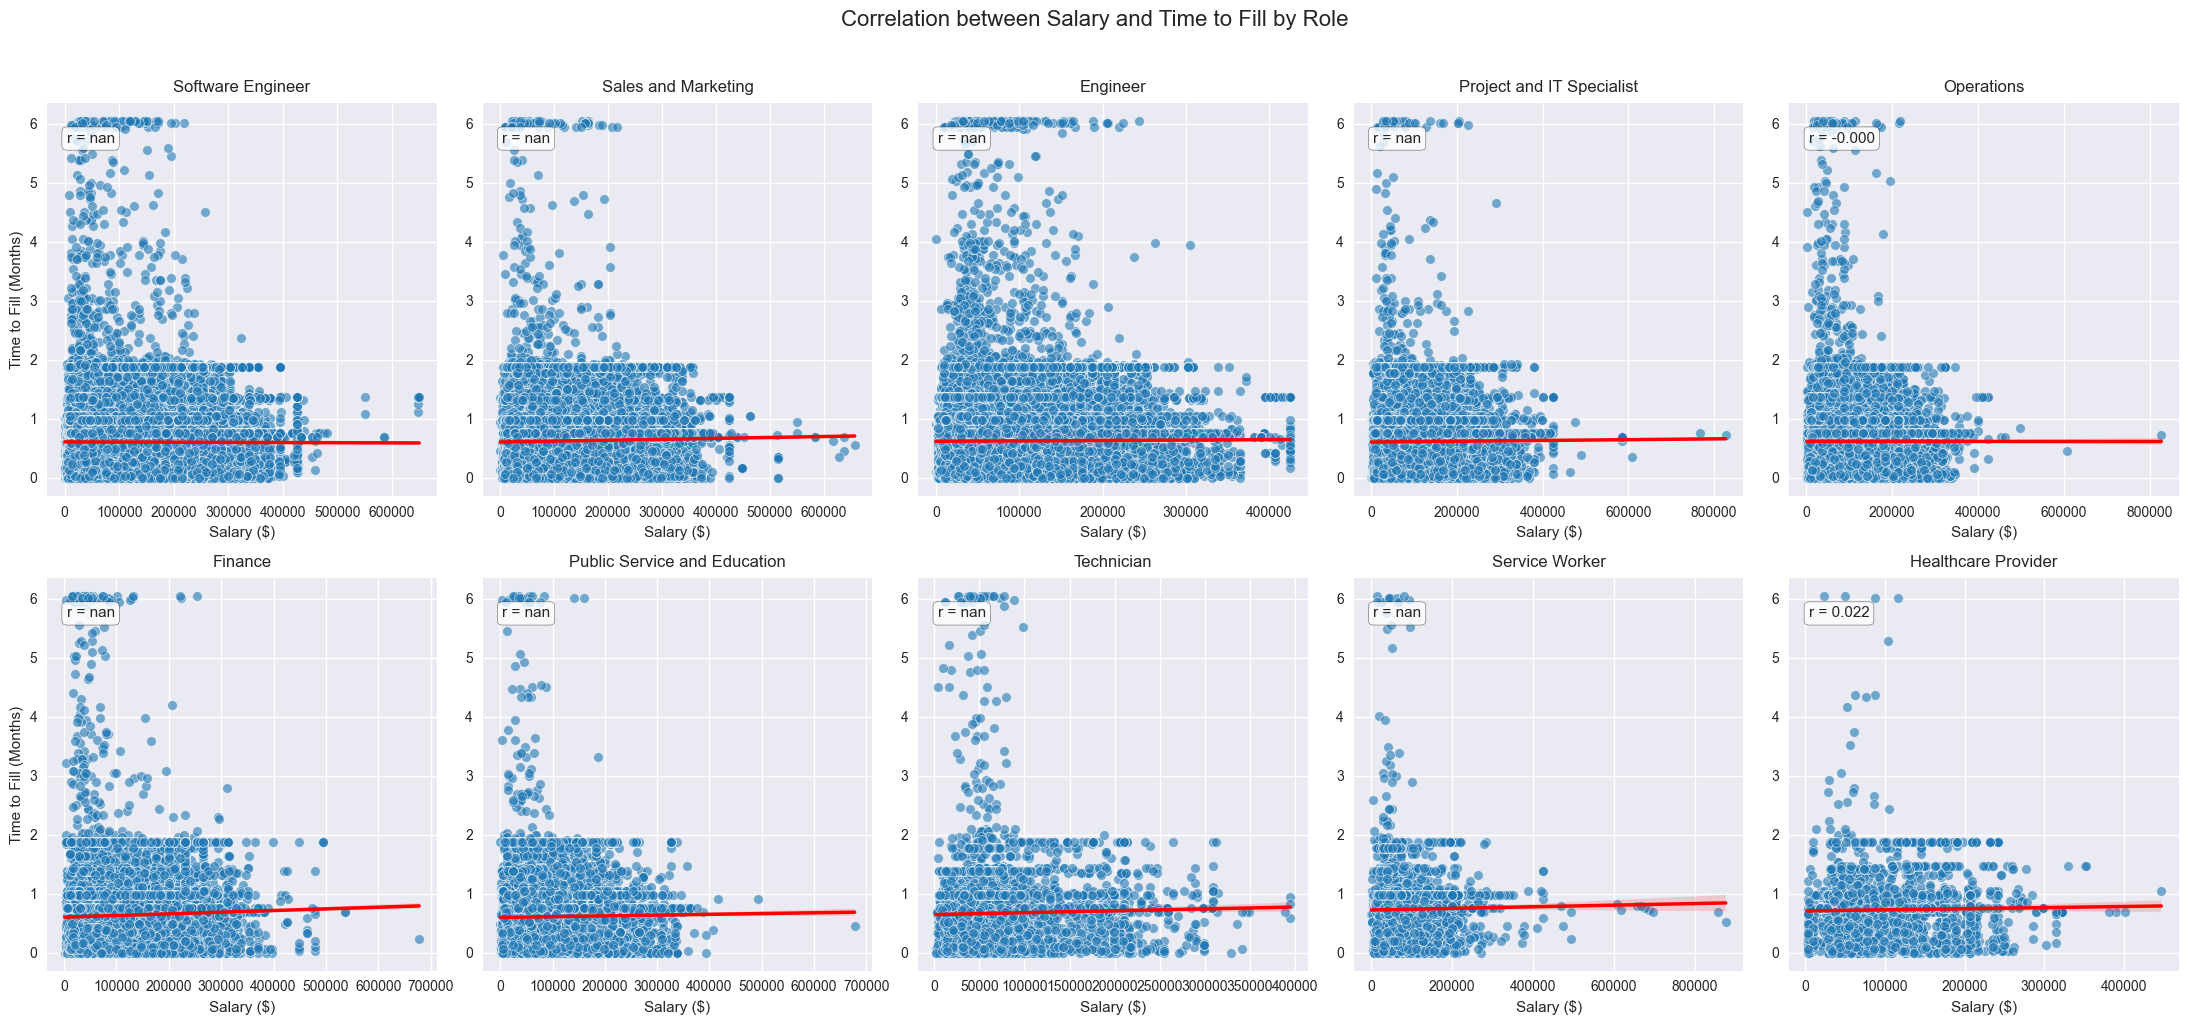

In [ ]:
# === Correlation between Salary and Time to Fill — by Role (2x5 grid) ===



fig, axes = plt.subplots(2, 5, figsize=(22, 10), sharey=False)
axes = axes.flatten()

for i, role in enumerate(role_order):
    ax = axes[i]
    data = df_clean[df_clean['role_k10'] == role].copy()
    
    # Scatter
    sns.scatterplot(
        data=data,
        y='salary',
        x='filling_time_months',
        ax=ax,
        alpha=0.6,
        color="#1f77b4"
    )
    
    # Regression line
    sns.regplot(
        data=data,
        y='salary',
        x='filling_time_months',
        ax=ax,
        scatter=False,
        line_kws={'color': 'red', 'linewidth': 2.5}
    )
    
    # Add correlation coefficient
    r, p = stats.pearsonr(data['salary'], data['filling_time_months'])
    ax.text(0.05, 0.9, f'r = {r:.3f}', transform=ax.transAxes, 
            fontsize=11, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    ax.set_title(f"{role}", fontsize=12, pad=8)
    ax.set_xlabel("Salary ($)")
    if i % 5 == 0:
        ax.set_ylabel("Time to Fill (Months)")
    else:
        ax.set_ylabel("")

# Hide any extra subplot
for j in range(len(role_order), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Correlation between Salary and Time to Fill by Role", 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()